<a href="https://colab.research.google.com/github/Marampawan/Predictive-Student-Risk-Analysis/blob/main/risk_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install xgboost

In [18]:
import pandas as pd

df = pd.read_csv("/content/student-por.csv")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [19]:
def risk_category(g3):
    if g3 < 10:
        return "High"
    elif g3 < 14:
        return "Medium"
    else:
        return "Low"

df["Risk_Category"] = df["G3"].apply(risk_category)

df["Risk_Category"].value_counts()

,count
Risk_Category,
Medium,355
Low,194
High,100


In [20]:
df = df.drop("G3", axis=1)

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

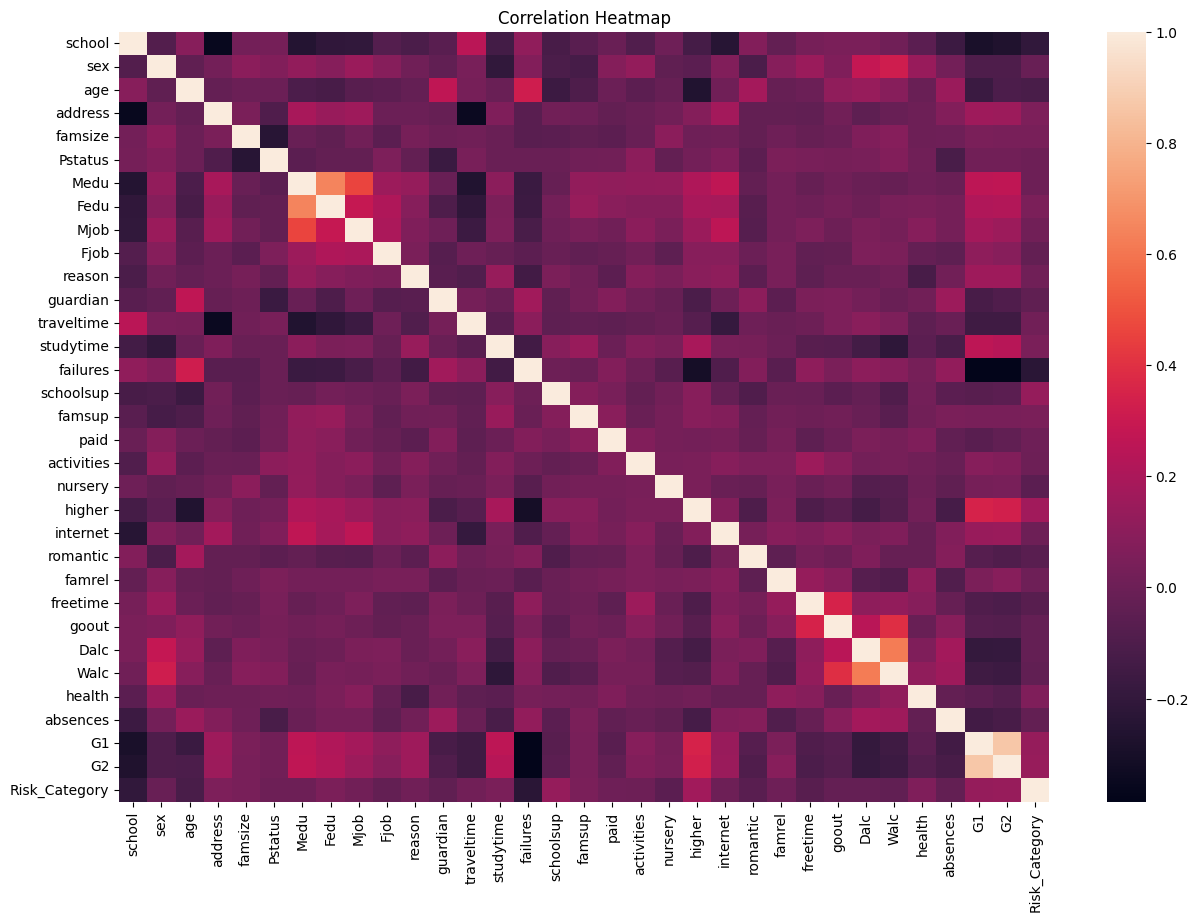

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(df.corr())
plt.title("Correlation Heatmap")
plt.show()

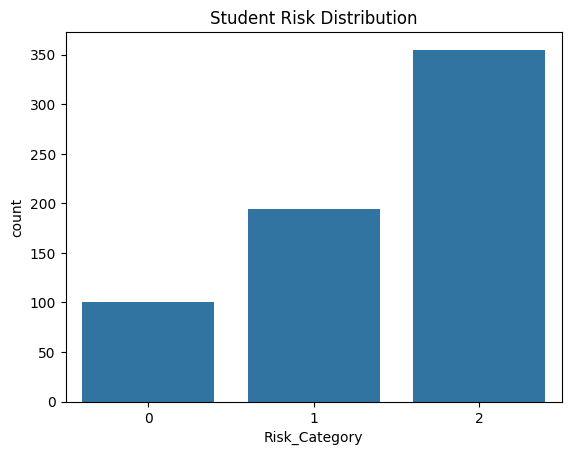

In [23]:
sns.countplot(x="Risk_Category", data=df)

plt.title("Student Risk Distribution")
plt.show()

In [24]:
df = df.sample(n=1000, replace=True, random_state=42)

In [25]:
from sklearn.model_selection import train_test_split

X = df.drop("Risk_Category", axis=1)

y = df["Risk_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.88      0.88        26
           1       1.00      0.89      0.94        64
           2       0.91      0.97      0.94       110

    accuracy                           0.94       200
   macro avg       0.93      0.92      0.92       200
weighted avg       0.94      0.94      0.93       200



In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        26
           1       0.98      0.94      0.96        64
           2       0.93      0.95      0.94       110

    accuracy                           0.93       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.93      0.93      0.93       200



In [29]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print(classification_report(y_test, svm_pred))

              precision    recall  f1-score   support

           0       0.81      0.96      0.88        26
           1       0.90      0.86      0.88        64
           2       0.91      0.89      0.90       110

    accuracy                           0.89       200
   macro avg       0.87      0.90      0.89       200
weighted avg       0.89      0.89      0.89       200



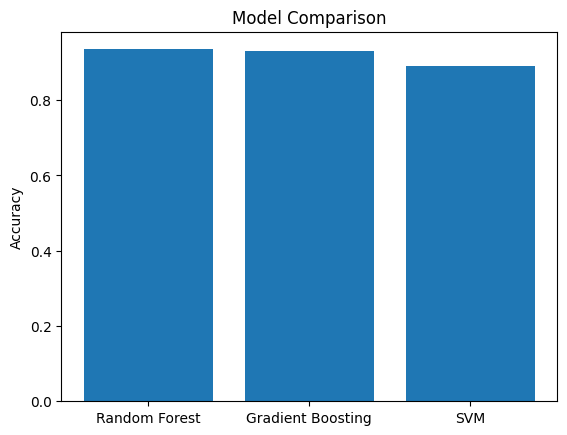

In [30]:
from sklearn.metrics import accuracy_score

models = ["Random Forest","Gradient Boosting","SVM"]

acc = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, svm_pred)
]

plt.bar(models, acc)

plt.title("Model Comparison")

plt.ylabel("Accuracy")

plt.show()

In [31]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

     Feature  Importance
31        G2    0.336062
30        G1    0.175223
14  failures    0.033316
29  absences    0.032933
25     goout    0.029348
2        age    0.026771
24  freetime    0.026315
8       Mjob    0.022213
27      Walc    0.020806
26      Dalc    0.020049


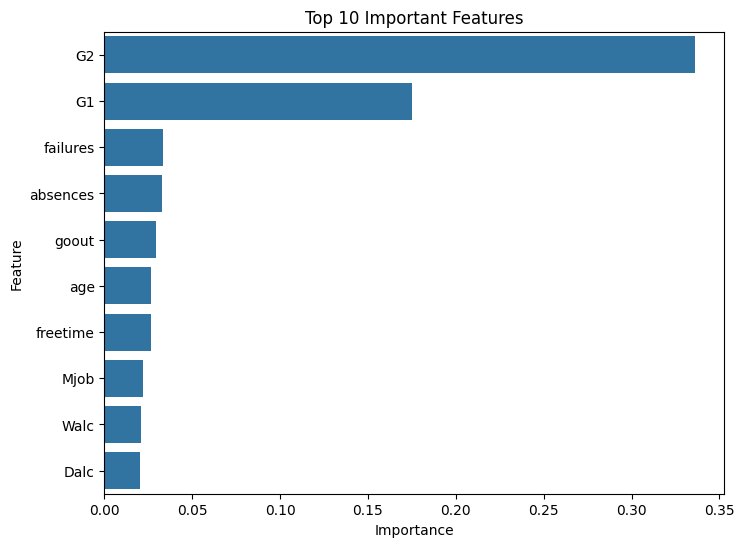

In [32]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()